# Energy consumption optimization



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Dense

#Load Energy + Weather Data

In [ ]:
energy =pd.read_csv("/content/energy.csv")

In [ ]:
weather =pd.read_csv("/content/weather.csv")

# Preprocessing — Convert timestamps & merge datasets


In [ ]:
energy['timestamp'] = pd.to_datetime(energy['timestamp'])

In [ ]:
weather['timestamp'] = pd.to_datetime(weather['timestamp'])

#Align by timestamp (inner join)

In [ ]:
df = pd.merge(energy, weather, on='timestamp', how='inner')
df =df.sort_values('timestamp')
df.head()

,timestamp,energy_kWh,temperature_C,humidity_%
0,2025-01-01 00:00:00,1.875,27.73,48.29
1,2025-01-01 01:00:00,1.909,28.24,52.52
2,2025-01-01 02:00:00,2.147,27.25,60.68
3,2025-01-01 03:00:00,2.382,25.77,66.98
4,2025-01-01 04:00:00,2.198,27.47,59.75


# feature Engineering

In [ ]:
df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day
df['weekday'] = df['timestamp'].dt.weekday
df['month'] = df['timestamp'].dt.month

 # Normalize/Scale Features


In [ ]:
scaler =MinMaxScaler()


scaled_df = scaler.fit_transform(df[['energy_kWh','temperature_C','humidity_%','hour','day','weekday','month']])
scaled_df = pd.DataFrame(scaled_df, columns=['energy','temp','hum','hour','day','weekday','month'])

# Random Forest Regression Model



In [ ]:
X = scaled_df.drop('energy', axis=1)
y = scaled_df['energy']

X_train, X_test, y_train, y_test =train_test_split(
    X, y,test_size=0.2, shuffle=False
)

rf =RandomForestRegressor(n_estimators=200)
rf.fit(X_train, y_train)
rf_pred =rf.predict(X_test)

# Evaluate Random forest

In [ ]:
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_rmse

np.float64(0.09286305423448517)

#Plot Predictions vs Actual


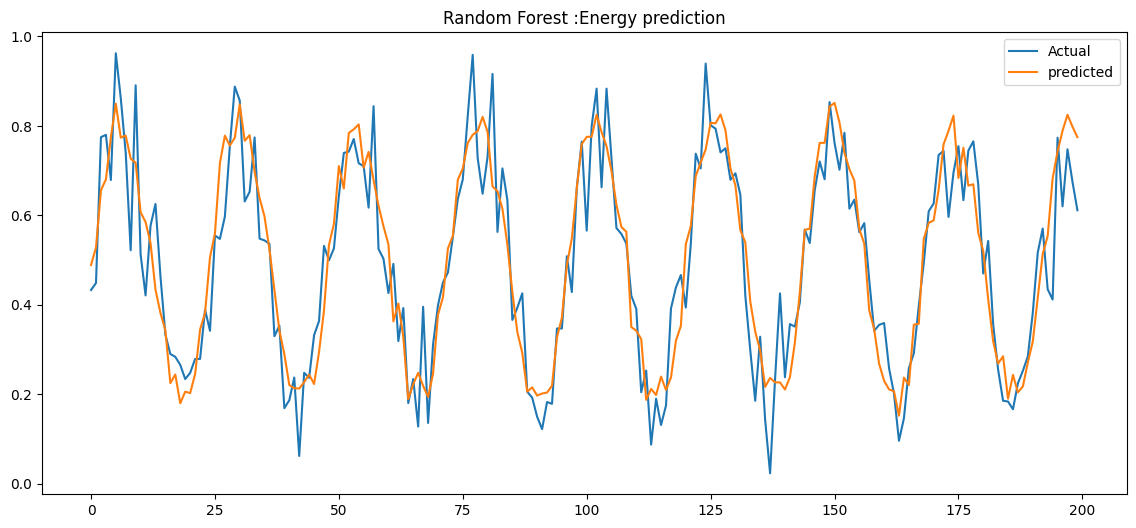

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(y_test.values[:200], label='Actual')
plt.plot(rf_pred[:200], label='predicted')
plt.title("Random Forest :Energy prediction")
plt.legend()
plt.show()

#LSTM Model (Deep Learning)


In [ ]:
def create_sequences(data, seq_length=24):
  X, y = [], []
  for i in range(len(data) - seq_length):
      X.append(data[i: i+seq_length])
      y.append(data[i+seq_length][0]) # energy column
  return np.array(X), np.array(y)

seq_data = scaled_df[['energy','temp','hum','hour','day','weekday','month']].values
X_seq, y_seq = create_sequences(seq_data)

# Split sequences

In [ ]:
split = int(0.8 * len(X_seq))
X_train_seq, X_test_seq = X_seq[:split], X_seq[split:]
y_train_seq, y_test_seq = y_seq[:split], y_seq[split:]

#
Build LSTM model


In [ ]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    LSTM(32),
    Dense(1)
])

model.compile(loss='mse', optimizer='adam')
model.summary()

history =model.fit(
    X_train_seq, y_train_seq,
    epochs=10, batch_size=32,
    validation_split=0.1,
    verbose=1
)

lstm_pred = model.predict(X_test_seq)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,881 (120.63 KB)

 Trainable params: 30,881 (120.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 0.0787 - val_loss: 0.0262
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0145 - val_loss: 0.0095
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0085 - val_loss: 0.0082
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0071 - val_loss: 0.0081
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0074 - val_loss: 0.0088
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0083 - val_loss: 0.0085
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0076 - val_loss: 0.0083
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0076 - val_loss: 0.0084
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0080 - val_loss: 0.0077
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0077 - val_loss: 0.0081
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step


# Evaluate

In [ ]:


lstm_rmse = np.sqrt(mean_squared_error(y_test_seq, lstm_pred))
lstm_rmse



np.float64(0.09091662181404785)

# Visualize LSTM Predictions

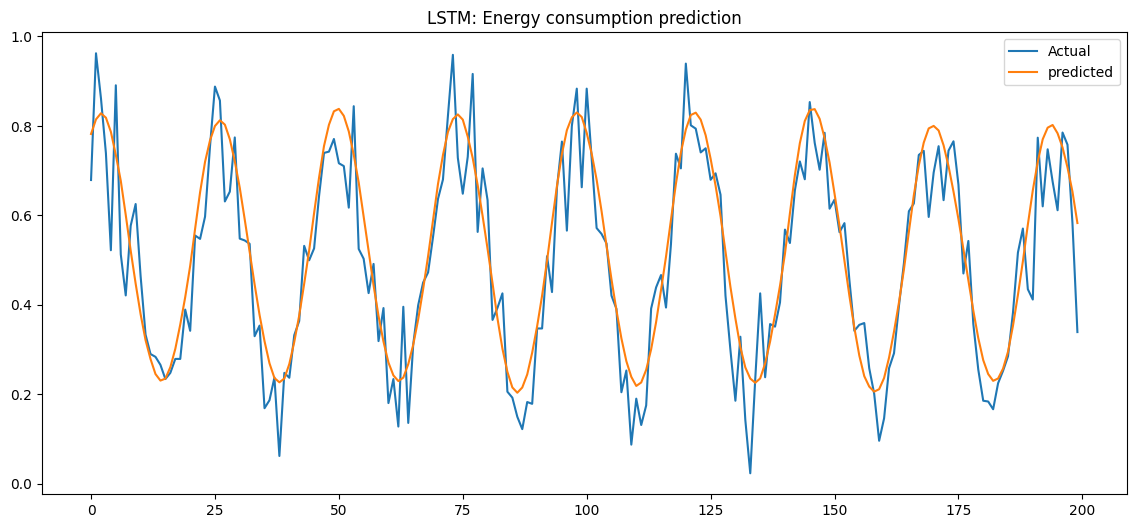

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(y_test_seq[:200], label='Actual')
plt.plot(lstm_pred[:200], label='predicted')
plt.title("LSTM: Energy consumption prediction")
plt.legend()
plt.show()


# Optimization: Suggest Energy-Saving Strategies

# Identify peak usage hours:

In [ ]:
df['predicted_rf'] = rf.predict(X)
peak = df.groupby('hour')['predicted_rf'].mean().sort_values(ascending=False)
peak.head()


,predicted_rf
hour,
6,0.790191
5,0.780818
7,0.761500
4,0.748964
8,0.740276


# Identify low-cost hours:

In [ ]:
low_usage = df.groupby('hour')['predicted_rf'].mean().sort_values().head()
low_usage


,predicted_rf
hour,
19,0.220992
18,0.221544
17,0.233641
16,0.237014
20,0.240351


# Energy-Saving Recommendation Logic

In [ ]:
print("⚡ Suggested Energy Saving Plan:\n")

print("Peak Hours (avoid heavy appliances):")
print(list(peak.index[:3]))

print("\nOptimal Hours (cheapest usage):")
print(list(low_usage.index[:3]))

print("\nRecommendation:")
print("• Run AC/Washing Machine during low-usage hours.")
print("• Reduce appliance usage during peak hours to cut energy cost.")
print("• Shift industrial load to off-peak time slots.")


⚡ Suggested Energy Saving Plan:

Peak Hours (avoid heavy appliances):
[6, 5, 7]

Optimal Hours (cheapest usage):
[19, 18, 17]

Recommendation:
• Run AC/Washing Machine during low-usage hours.
• Reduce appliance usage during peak hours to cut energy cost.
• Shift industrial load to off-peak time slots.


In [ ]:
print("Random Forest RMSE:", rf_rmse)
print("LSTM RMSE:", lstm_rmse)



Random Forest RMSE: 0.09286305423448517
LSTM RMSE: 0.09091662181404785
